# 🤖 SEMAINE 3 : Modélisation Simple

**Projet:** Détection précoce DT1 - Cameroun  
**Objectifs:**
- Entraîner plusieurs algorithmes de classification de base
- Comparer les performances (Accuracy, Recall, Precision, F1-score)
- Comprendre les forces et faiblesses de chaque algorithme
- Sélectionner le meilleur modèle de base

**Algorithmes testés:**
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

**Durée estimée:** 12-14 heures

---

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


In [2]:
# Charger les données
df = pd.read_csv('../2_DONNEES/processed/dataset_clean.csv')

# Préparer X et y
features = ['age', 'IMC', 'glycemie_jeun', 'HbA1c', 'ANP32A_IT1', 'ESCO2', 'NBPF1']
X = df[features]
y = df['diagnostic']

# Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisation (nécessaire pour SVM et Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📂 Données chargées: {X.shape[0]} patients, {X.shape[1]} features")
print(f"   Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"   Proportion DT1: {y.mean()*100:.1f}%")

📂 Données chargées: 1000 patients, 7 features
   Train: 800 | Test: 200
   Proportion DT1: 25.0%


## 🔵 Modèle 1 : Logistic Regression

Régression logistique = algorithme linéaire simple mais puissant pour la classification binaire.

In [3]:
print("🔵 LOGISTIC REGRESSION\n")

# Entraîner le modèle
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Métriques
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Accuracy:  {acc_lr*100:.2f}%")
print(f"Precision: {prec_lr*100:.2f}%")
print(f"Recall:    {rec_lr*100:.2f}%  ⭐ (Prioritaire en médecine)")
print(f"F1-score:  {f1_lr:.3f}")
print(f"AUC-ROC:   {auc_lr:.3f}")

print("\n📋 Rapport de classification:")
print(classification_report(y_test, y_pred_lr, target_names=['Sain', 'DT1']))

🔵 LOGISTIC REGRESSION

Accuracy:  99.50%
Precision: 98.04%
Recall:    100.00%  ⭐ (Prioritaire en médecine)
F1-score:  0.990
AUC-ROC:   1.000

📋 Rapport de classification:
              precision    recall  f1-score   support

        Sain       1.00      0.99      1.00       150
         DT1       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



## 🌳 Modèle 2 : Decision Tree

Arbre de décision = règles if-then faciles à interpréter.

In [4]:
print("🌳 DECISION TREE\n")

# Entraîner le modèle
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)

# Prédictions
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

# Métriques
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

print(f"Accuracy:  {acc_dt*100:.2f}%")
print(f"Precision: {prec_dt*100:.2f}%")
print(f"Recall:    {rec_dt*100:.2f}%  ⭐")
print(f"F1-score:  {f1_dt:.3f}")
print(f"AUC-ROC:   {auc_dt:.3f}")

print("\n📋 Rapport de classification:")
print(classification_report(y_test, y_pred_dt, target_names=['Sain', 'DT1']))

🌳 DECISION TREE

Accuracy:  99.50%
Precision: 98.04%
Recall:    100.00%  ⭐
F1-score:  0.990
AUC-ROC:   1.000

📋 Rapport de classification:
              precision    recall  f1-score   support

        Sain       1.00      0.99      1.00       150
         DT1       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



## 🌲 Modèle 3 : Random Forest

Random Forest = ensemble de nombreux arbres de décision (bagging).

In [5]:
print("🌲 RANDOM FOREST\n")

# Entraîner le modèle
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, 
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Métriques
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Accuracy:  {acc_rf*100:.2f}%")
print(f"Precision: {prec_rf*100:.2f}%")
print(f"Recall:    {rec_rf*100:.2f}%  ⭐")
print(f"F1-score:  {f1_rf:.3f}")
print(f"AUC-ROC:   {auc_rf:.3f}")

print("\n📋 Rapport de classification:")
print(classification_report(y_test, y_pred_rf, target_names=['Sain', 'DT1']))

# Feature importance
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n🔍 Importance des features:")
print(feature_importance_df)

🌲 RANDOM FOREST

Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%  ⭐
F1-score:  1.000
AUC-ROC:   1.000

📋 Rapport de classification:
              precision    recall  f1-score   support

        Sain       1.00      1.00      1.00       150
         DT1       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


🔍 Importance des features:
         Feature  Importance
2  glycemie_jeun    0.363449
3          HbA1c    0.344802
5          ESCO2    0.135459
4     ANP32A_IT1    0.070432
6          NBPF1    0.055297
0            age    0.019402
1            IMC    0.011158


## ⚙️ Modèle 4 : Support Vector Machine (SVM)

SVM = trouve l'hyperplan optimal de séparation entre classes.

In [6]:
print("⚙️ SUPPORT VECTOR MACHINE\n")

# Entraîner le modèle
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
#Le "kernel" définit comment SVM transforme l'espace pour séparer les classes.
# kernel='rbf': Projette les données dans un **espace de dimension supérieure** pour les séparer.
# gamma='scale':   Contrôle la **courbure** de la frontière de décision (influence de chaque point).
# C=1.0:  Maximiser la marge (espace entre les classes) et Minimiser les erreurs de classification


# Prédictions
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Métriques
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

print(f"Accuracy:  {acc_svm*100:.2f}%")
print(f"Precision: {prec_svm*100:.2f}%")
print(f"Recall:    {rec_svm*100:.2f}%  ⭐")
print(f"F1-score:  {f1_svm:.3f}")
print(f"AUC-ROC:   {auc_svm:.3f}")

print("\n📋 Rapport de classification:")
print(classification_report(y_test, y_pred_svm, target_names=['Sain', 'DT1']))

⚙️ SUPPORT VECTOR MACHINE

Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%  ⭐
F1-score:  1.000
AUC-ROC:   1.000

📋 Rapport de classification:
              precision    recall  f1-score   support

        Sain       1.00      1.00      1.00       150
         DT1       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 📊 Comparaison des Modèles

📊 COMPARAISON DES MODÈLES

                Modèle  Accuracy  Precision  Recall  F1-score  AUC-ROC
0  Logistic Regression     0.995       0.98     1.0      0.99      1.0
1        Decision Tree     0.995       0.98     1.0      0.99      1.0
2        Random Forest     1.000       1.00     1.0      1.00      1.0
3                  SVM     1.000       1.00     1.0      1.00      1.0

⭐ Meilleur Recall: Logistic Regression (100.00%)


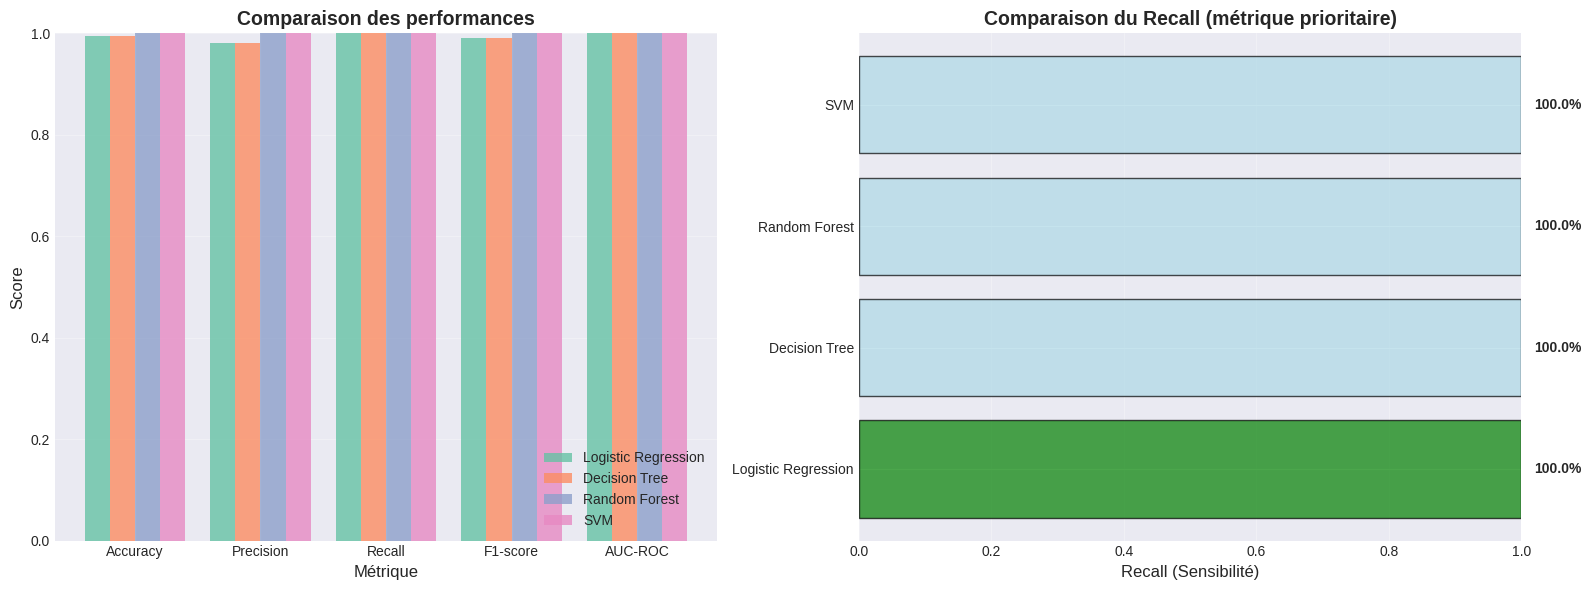

In [7]:
# Tableau comparatif
resultats = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [acc_lr, acc_dt, acc_rf, acc_svm],
    'Precision': [prec_lr, prec_dt, prec_rf, prec_svm],
    'Recall': [rec_lr, rec_dt, rec_rf, rec_svm],
    'F1-score': [f1_lr, f1_dt, f1_rf, f1_svm],
    'AUC-ROC': [auc_lr, auc_dt, auc_rf, auc_svm]
})

print("📊 COMPARAISON DES MODÈLES\n")
print(resultats.round(3))

# Identifier le meilleur modèle selon le Recall
best_recall_idx = resultats['Recall'].idxmax()
best_model = resultats.loc[best_recall_idx, 'Modèle']
best_recall = resultats.loc[best_recall_idx, 'Recall']

print(f"\n⭐ Meilleur Recall: {best_model} ({best_recall*100:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Comparaison des métriques
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.2

for i, (idx, row) in enumerate(resultats.iterrows()):
    axes[0].bar(x + i*width, row[metrics], width, label=row['Modèle'], alpha=0.8)

axes[0].set_xlabel('Métrique', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Comparaison des performances', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# Graphique 2: Focus sur Recall
colors = ['green' if m == best_model else 'lightblue' for m in resultats['Modèle']]
axes[1].barh(resultats['Modèle'], resultats['Recall'], color=colors, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Recall (Sensibilité)', fontsize=12)
axes[1].set_title('Comparaison du Recall (métrique prioritaire)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, 1)

# Ajouter les valeurs
for i, v in enumerate(resultats['Recall']):
    axes[1].text(v + 0.02, i, f'{v*100:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

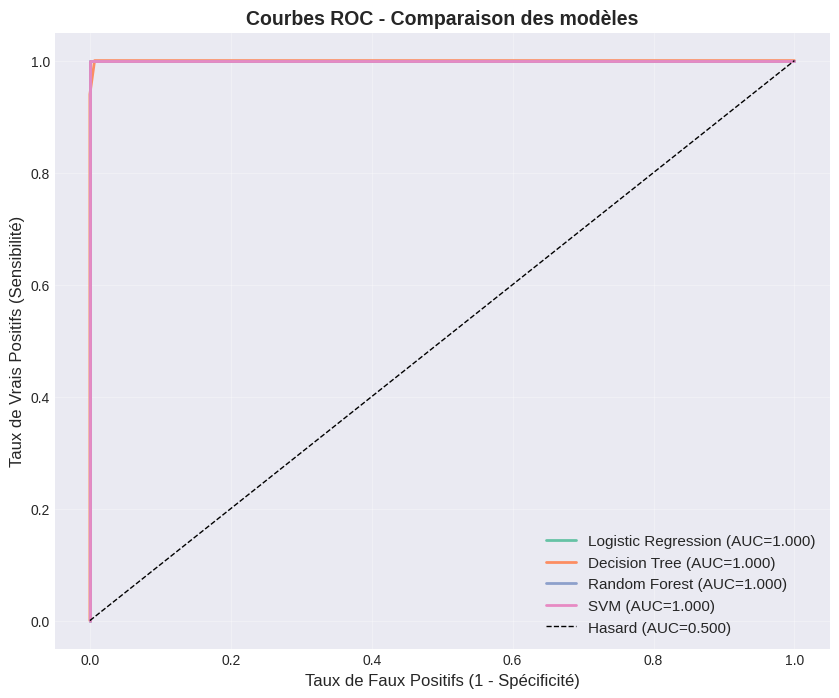

💡 Une courbe plus proche du coin supérieur gauche = meilleur modèle


In [8]:
# Courbes ROC comparatives
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f'Decision Tree (AUC={auc_dt:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC={auc_rf:.3f})')

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
plt.plot(fpr_svm, tpr_svm, linewidth=2, label=f'SVM (AUC={auc_svm:.3f})')

# Ligne de référence
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC=0.500)')

plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print("💡 Une courbe plus proche du coin supérieur gauche = meilleur modèle")

## 🎯 Conclusion et Recommandations

### Points clés:

1. **Métrique prioritaire:** Recall (sensibilité) car il faut minimiser les Faux Négatifs en médecine
2. **Meilleur modèle de base:** À déterminer selon vos résultats (souvent Random Forest)
3. **Prochaines étapes:**
   - Optimiser les hyperparamètres (GridSearch, RandomSearch)
   - Tester des algorithmes avancés (XGBoost, LightGBM)
   - Gérer le déséquilibre des classes (SMOTE, class_weight)

### 📅 Prochaine étape:
**Semaines 4-5:** Modèles avancés (XGBoost, LightGBM) et gestion du déséquilibre

---

*Notebook créé pour le projet DT1 Cameroun - Master 2 Biophysique - 2025*